In [15]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from mpl_toolkits.mplot3d import Axes3D
from abc import ABC, abstractmethod
import math
import re
from scipy.optimize import minimize
from itertools import product
import seaborn as sns
from matplotlib import animation
import time
%pip install -U numba numba-cuda cupy-cuda12x
import numba as nb
from numba import cuda
import cupy as cp

FORCE_MAT_TILE_DIM = 32
SPACE_N_DIM = 3

IDENTITY = 0
HARMONIC = 1
REPULSIVE = 2
ATTRACTIVE = 3

BOX_SIZE_IDX = 0
K_IDX = 1
R0_IDX = 2
EPSILON_ATTRACTIVE_IDX = 3
EPSILON_REPULSIVE_IDX = 4
SIGMA_IDX = 5

NB_FLOAT32 = 32
NB_FLOAT64 = 64

DIV_BY_ZERO_GUARD = 1e-12

In [2]:
def apply_pbc(position, box_size):
    return position % box_size

In [3]:
@nb.njit
def apply_pbc(pos: np.ndarray | cp.ndarray | float, box_size: float) -> np.ndarray | cp.ndarray:
    """
    Wraps the chain inside the unit cell
    """
    return pos % box_size

@nb.njit
def assign_position(positions, new_positions, idx):
    positions[0, idx] = new_positions[0]
    positions[1, idx] = new_positions[1]
    positions[2, idx] = new_positions[2]

@nb.njit
def initialize_chain_numba(
    n_particles: int,
    box_size: float,
    r0: float,
    rng: np.random._generator.Generator,
    dtype=np.float32
) -> np.ndarray:
    """
    Randomly initialize atom positions by growing the chain
    """
    positions = np.zeros((3, n_particles), dtype=dtype)

    current_position = np.array([box_size / 2, box_size / 2, box_size / 2], dtype=dtype)
    assign_position(positions, current_position, 0)

    for i in range(1, n_particles):
        direction = rng.normal(size = 3).astype(dtype)
        norm = np.sqrt(direction[0]**2 + direction[1]**2 + direction[2]**2)
        direction /= norm

        next_position = current_position + r0 * direction
        next_position = apply_pbc(next_position, box_size).astype(dtype)
        assign_position(positions, next_position, i)
        current_position = next_position

    return positions

def initialize_velocities_cupy(
    n_particles: int,
    target_temperature: float, 
    mass: float,
    rng: cp.random._generator_api.Generator,
    kB=1.0,
    dtype=cp.float32
) -> cp.ndarray:
    """
    Initialize particle velocities by drawing from the Maxwell-Botzmann distribution at target temperature
    """
    sigma = cp.sqrt(kB * target_temperature / mass).astype(dtype)

    velocities = rng.standard_normal(
        size=(3, n_particles), 
        dtype=dtype
    )
    velocities = velocities * sigma

    # Remove center-of-mass velocity
    velocities -= cp.mean(velocities, axis=-1).reshape(3, 1)

    return velocities

## GPU Code

In [4]:
@cuda.jit
def atom_label_kernel(
    labels, # global labels array (output)
    positions, # global positions array (input)
    cell_size: float, # size of each cell
    dim: int # number of cell in each dimension
):
    idx = cuda.grid(1)
    if idx >= positions.shape[1]:
        return
    x = positions[0, idx]
    y = positions[1, idx]
    z = positions[2, idx]
    cell_x = int(x // cell_size) % dim
    cell_y = int(y // cell_size) % dim
    cell_z = int(z // cell_size) % dim
    
    labels[idx] = cell_x + cell_y * dim + cell_z * dim * dim

In [5]:
@cuda.jit(device=True)
def minimum_image_d(dx, box_size):
    if dx > 0.5 * box_size:
        dx -= box_size
    elif dx < -0.5 * box_size:
        dx += box_size
    return dx

@cuda.jit(device=True)
def harmonic_force_d(r, k, r0):
    return -k * (r - r0)

well_coeff = 1.122462048309373

@cuda.jit(device=True)
def repulsive_lj_force_d(r, sigma, epsilon):
    if r < well_coeff * sigma:
        if r < DIV_BY_ZERO_GUARD:
            r = DIV_BY_ZERO_GUARD
        sixth_pow = (sigma / r) ** 6
        return -24.0 * epsilon / r * (sixth_pow - 2.0 * sixth_pow * sixth_pow)
    else:
        return 0.0

@cuda.jit(device=True)
def attractive_lj_force_d(r, sigma, epsilon):
    if r < DIV_BY_ZERO_GUARD:
        r = DIV_BY_ZERO_GUARD
    sixth_pow = (sigma / r) ** 6
    return -24.0 * epsilon / r * (sixth_pow - 2.0 * sixth_pow * sixth_pow)

@cuda.jit(device=True)
def calc_force_d(distance, params, sep):
    if sep == HARMONIC:
        return harmonic_force_d(distance, params[K_IDX], params[R0_IDX])
    elif sep == REPULSIVE:
        return repulsive_lj_force_d(distance, params[SIGMA_IDX], params[EPSILON_REPULSIVE_IDX])
    elif sep >= ATTRACTIVE:
        return attractive_lj_force_d(distance, params[SIGMA_IDX], params[EPSILON_ATTRACTIVE_IDX])
    return 0.0

@cuda.jit
def force_computation(
    forces,
    cell_start,
    positions,
    org_idx,
    const_params,
    cell_size,
    box_size,
    n_cells
):
    i = cuda.grid(1)

    if i >= positions.shape[1]:
        return

    i_o = org_idx[i]

    xi = positions[0, i]
    yi = positions[1, i]
    zi = positions[2, i]

    cx = int((xi % box_size) // cell_size)
    cy = int((yi % box_size) // cell_size)
    cz = int((zi % box_size) // cell_size)

    force_x = 0.0
    force_y = 0.0
    force_z = 0.0

    for dz in range(-1, 2):
        nz = (cz + dz + n_cells) % n_cells

        for dy in range(-1, 2):
            ny = (cy + dy + n_cells) % n_cells

            for dx in range(-1, 2):
                nx = (cx + dx + n_cells) % n_cells

                nbr = nx + ny * n_cells + nz * n_cells * n_cells

                start = cell_start[nbr]
                end = cell_start[nbr + 1]

                for j in range(start, end):
                    if j == i:
                        continue

                    xj = positions[0, j]
                    yj = positions[1, j]
                    zj = positions[2, j]

                    xij = minimum_image_d(xi - xj, box_size)
                    yij = minimum_image_d(yi - yj, box_size)
                    zij = minimum_image_d(zi - zj, box_size)

                    r2 = xij * xij + yij * yij + zij * zij
                    if r2 < DIV_BY_ZERO_GUARD * DIV_BY_ZERO_GUARD:
                        continue

                    rij = math.sqrt(r2)

                    j_o = org_idx[j]
                    sep = abs(j_o - i_o)

                    fmag = calc_force_d(rij, const_params, sep)

                    force_x += fmag * xij / rij
                    force_y += fmag * yij / rij
                    force_z += fmag * zij / rij

    forces[0, i_o] = force_x
    forces[1, i_o] = force_y
    forces[2, i_o] = force_z

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 79 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 79 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


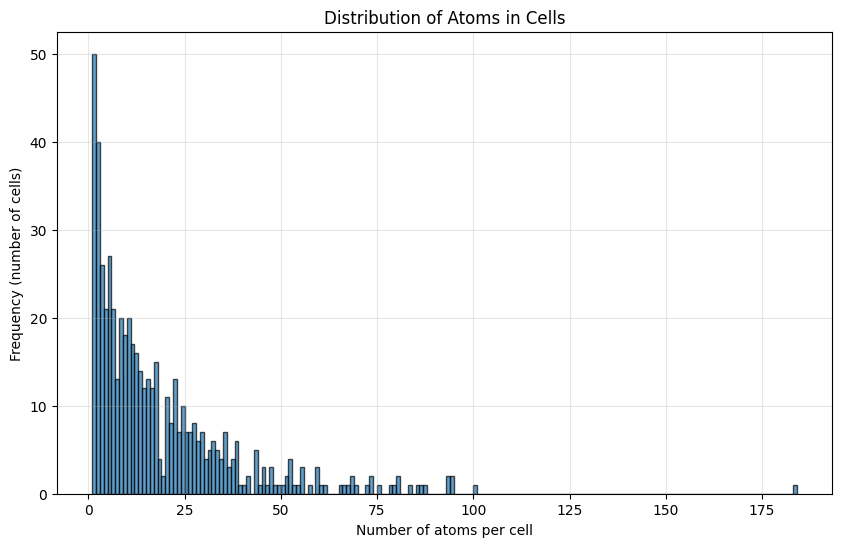

In [ ]:
rng_np = np.random.default_rng(42)
box_size = 100.0
n = 10000
pos_1 = initialize_chain_numba(n, box_size, 1.0, rng_np, dtype = np.float64)
# print(pos.shape)
positions_d = cp.array(pos_1)
labels_d = cp.zeros(positions_d.shape[1], dtype=cp.int32)
block_size = 128
grid_size = (positions_d.shape[1] + block_size - 1) // block_size
dim = 20
cell_size = box_size / dim

atom_label_kernel[grid_size, block_size](labels_d, positions_d, cell_size, 20)
cuda.synchronize()

order = cp.argsort(labels_d)
labels_sorted = labels_d[order]
positions_sorted = positions_d[:, order]
orig_idx_sorted = order

# for i in range(10):
#     print(labels_sorted[i], positions_sorted[:, i])

dim = 20
cell_size = box_size / dim
n_total_cells = dim**3

counts = cp.bincount(labels_sorted, minlength=n_total_cells)
cell_start = cp.zeros(n_total_cells + 1, dtype=cp.int32)
cell_start[1:] = cp.cumsum(counts)

forces_1 = cp.zeros_like(positions_d)
const_params_1 = cp.array([100, 300, 1, 0.5, 1.0, 1.0], dtype=cp.float64)

forces_nb = cuda.as_cuda_array(forces_1)
cell_start_nb = cuda.as_cuda_array(cell_start)
positions_sorted_nb = cuda.as_cuda_array(positions_sorted)
orig_idx_sorted_nb = cuda.as_cuda_array(orig_idx_sorted)
const_params_nb = cuda.as_cuda_array(const_params_1)

force_computation[grid_size, block_size](
    forces_nb,
    cell_start_nb,
    positions_sorted_nb,
    orig_idx_sorted_nb,
    const_params_nb,
    cell_size,
    box_size,
    dim
)
cuda.synchronize()


# Get the counts as numpy array for plotting
counts_np = counts.get()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(counts_np, bins=range(1, int(counts_np.max()) + 2), edgecolor='black', alpha=0.7)
plt.xlabel('Number of atoms per cell')
plt.ylabel('Frequency (number of cells)')
plt.title('Distribution of Atoms in Cells')
plt.grid(True, alpha=0.3)
plt.show()



In [7]:
print(cp.asnumpy(forces_1))

[[-2.52854841e+07 -3.77869360e+05  7.91022355e+03 ... -7.95279445e-01
  -1.23773602e+02  5.86620773e-01]
 [-1.10749700e+07  3.14572448e+05  1.17366180e+04 ... -1.58780574e+01
   1.15691159e+01 -6.40442452e-01]
 [ 9.23030897e+06 -6.53955228e+05 -1.81171824e+04 ... -1.05725217e+01
  -9.66690328e+01  2.72232378e-01]]


## Sequential Version

In [8]:
@nb.njit
def harmonic_force_h(r, k, r0):
  return -k * (r-r0)

well_coeff = 2**(1/6)
@nb.njit
def repulsive_lj_force_h(r, sigma, epsilon):
  if r < well_coeff*sigma:
    r = max(r, DIV_BY_ZERO_GUARD)
    sixth_pow = (sigma/r) ** 6
    return -24*epsilon/r * (sixth_pow - 2*(sixth_pow**2))
  else:
    return 0

@nb.njit
def attractive_lj_force_h(r, sigma, epsilon):
  r = max(r, DIV_BY_ZERO_GUARD)
  sixth_pow = (sigma/r) ** 6
  return -24*epsilon/r * (sixth_pow - 2*(sixth_pow**2))

@nb.njit
def calc_force_h(distance, params, type):
  if type == HARMONIC or type == -HARMONIC:
     return harmonic_force_h(distance, params[K_IDX], params[R0_IDX])
  if type == REPULSIVE or type == -REPULSIVE:
     return repulsive_lj_force_h(distance, params[SIGMA_IDX], params[EPSILON_REPULSIVE_IDX])
  if type >= ATTRACTIVE or type <= -ATTRACTIVE:
     return attractive_lj_force_h(distance, params[SIGMA_IDX], params[EPSILON_ATTRACTIVE_IDX])
  return 0

@nb.njit
def minimum_image_1d_h(dx, box_size):
    return dx - box_size * round(dx / box_size)

@nb.njit
def calc_force_sequential_h(
  forces, # global forces array (output)
  positions, # global positions array (input)
  const_params
):
  params = const_params
  n_particles = positions.shape[1]
  for i in range(n_particles-1):
    for j in range(i+1, n_particles):
      distance = 0
      for k in range(SPACE_N_DIM):
        dx = minimum_image_1d_h(positions[k, i] - positions[k, j], params[BOX_SIZE_IDX])
        distance += dx**2
      distance = math.sqrt(distance)
      magnitude = calc_force_h(distance, params, j - i)
      for k in range(SPACE_N_DIM):
        f = magnitude * (positions[k, i] - positions[k, j]) / distance
        forces[k, i] += f
        forces[k, j] -= f

In [13]:
# pos_2 = initialize_chain_numba(n, box_size, 1.0, rng_np, dtype = np.float64)
const_params_2 = np.array([100, 300, 1, 0.5, 1.0, 1.0], dtype=np.float64)
forces_2 = np.zeros_like(pos_1, dtype=np.float64)

calc_force_sequential_h(forces_2, pos_1, const_params=const_params_2)

In [14]:
print(forces_2)

[[-2.52854841e+07 -3.77869361e+05  7.91022286e+03 ... -7.95326965e-01
  -1.23773791e+02  5.86685420e-01]
 [-1.10749700e+07  3.14572448e+05  1.17366176e+04 ... -1.58781823e+01
   1.15690894e+01 -6.40460398e-01]
 [ 9.23030897e+06 -6.53955229e+05 -1.81171825e+04 ... -1.05724800e+01
  -9.66689832e+01  2.72327566e-01]]


In [11]:
print(pos_1)
print("------------------")
print(pos_2)

[[50.         50.23116514 50.6033379  ... 26.45649018 25.86923859
  24.9382064 ]
 [50.         49.21104498 48.4390384  ... 45.19250851 45.99430498
  46.27138071]
 [50.         50.56930893 50.05404854 ... 13.69050437 13.80122016
  14.03872408]]
------------------
[[50.         50.90671119 50.30632079 ... 76.94844671 76.52550656
  76.93509562]
 [50.         50.1850689  50.15693345 ... 15.35123953 15.83384071
  15.96660496]
 [50.         49.621022   48.82181003 ... 59.85455596 60.62150949
  59.71895176]]


## Test Runtime

In [ ]:
rng_np = np.random.default_rng(42)
box_size = 100.0
n = 10000
pos_1 = initialize_chain_numba(n, box_size, 1.0, rng_np, dtype = np.float64)
# print(pos.shape)


In [ ]:
%%timeit
positions_d = cp.array(pos_1)
labels_d = cp.zeros(positions_d.shape[1], dtype=cp.int32)
block_size = 128
grid_size = (positions_d.shape[1] + block_size - 1) // block_size
dim = 20
cell_size = box_size / dim
atom_label_kernel[grid_size, block_size](labels_d, positions_d, cell_size, 20)
cuda.synchronize()

order = cp.argsort(labels_d)
labels_sorted = labels_d[order]
positions_sorted = positions_d[:, order]
orig_idx_sorted = order

# for i in range(10):
#     print(labels_sorted[i], positions_sorted[:, i])

dim = 20
cell_size = box_size / dim
n_total_cells = dim**3

counts = cp.bincount(labels_sorted, minlength=n_total_cells)
cell_start = cp.zeros(n_total_cells + 1, dtype=cp.int32)
cell_start[1:] = cp.cumsum(counts)

forces_1 = cp.zeros_like(positions_d)
const_params_1 = cp.array([100, 300, 1, 0.5, 1.0, 1.0], dtype=cp.float64)

forces_nb = cuda.as_cuda_array(forces_1)
cell_start_nb = cuda.as_cuda_array(cell_start)
positions_sorted_nb = cuda.as_cuda_array(positions_sorted)
orig_idx_sorted_nb = cuda.as_cuda_array(orig_idx_sorted)
const_params_nb = cuda.as_cuda_array(const_params_1)

force_computation[grid_size, block_size](
    forces_nb,
    cell_start_nb,
    positions_sorted_nb,
    orig_idx_sorted_nb,
    const_params_nb,
    cell_size,
    box_size,
    dim
)
cuda.synchronize()

UnboundLocalError: cannot access local variable 'cell_size' where it is not associated with a value

In [ ]:
%%timeit
forces_2 = np.zeros_like(pos_1, dtype=np.float64)

calc_force_sequential_h(forces_2, pos_1, const_params=const_params_2)